In [1]:
from utils import *

from sklearn.cluster import DBSCAN
from math import sqrt
from scipy.stats import norm
from scipy.stats import binom

In [2]:
mean_stdev = 0.001213525524
sd_stdev = 0.0005776370773
z = norm.ppf(0.99)
cutoff = mean_stdev + z*sd_stdev
round(cutoff, 5)

np.float64(0.00256)

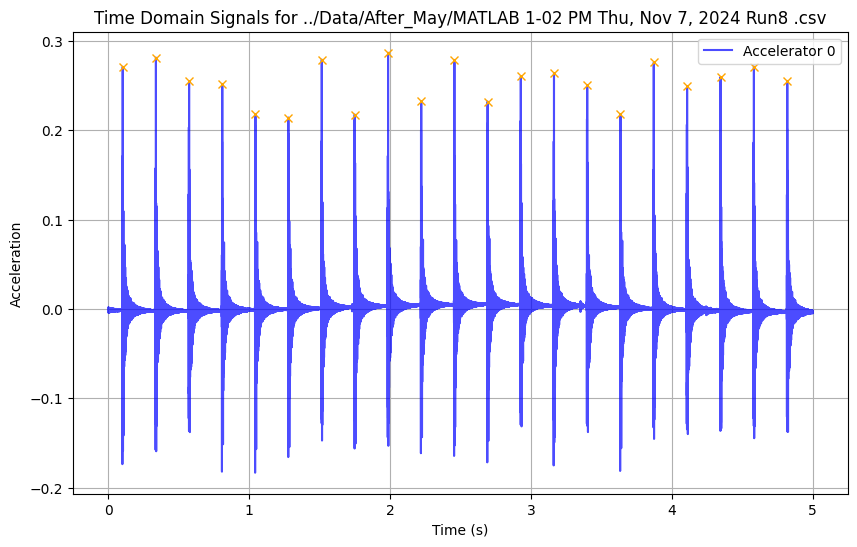

[0.1035 0.3391 0.5746 0.81   1.0454 1.2791 1.516  1.7496 1.9866 2.222
 2.4574 2.693  2.9286 3.1641 3.3999 3.6359 3.8722 4.1088 4.3458 4.5828
 4.8197]


In [3]:
# Single Rhythmic
file = '../Data/After_May/MATLAB 1-02 PM Thu, Nov 7, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-21 PM Thu, Nov 7, 2024 Run10 .csv'
# file ='Data/After_May/MATLAB 3-55 PM Thu, Sep 5, 2024 Run0 .csv'

# file = 'Data/After_May/MATLAB 1-00 PM Fri, Jun 28, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-51 PM Tue, Oct 29, 2024 Run13 .csv'
# file = 'Data/After_May/MATLAB 2-45 PM Thu, Oct 24, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 1-25 PM Thu, Nov 7, 2024 Run11 .csv'
# file = 'Data/After_May/MATLAB 2-21 PM Mon, Oct 28, 2024 Run4 .csv'
# file = 'Data/After_May/MATLAB 2-47 PM Mon, Oct 28, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 1-36 PM Thu, Nov 7, 2024 Run14 .csv'
# file = 'Data/After_May/MATLAB 1-38 PM Thu, Nov 7, 2024 Run15 .csv'
# file = 'Data/After_May/MATLAB 2-23 PM Thu, Oct 31, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 2-26 PM Thu, Oct 31, 2024 Run11 .csv'
# file = 'Data/After_May/MATLAB 1-31 PM Tue, Oct 29, 2024 Run7 .csv'
# file = 'Data/After_May/MATLAB 1-53 PM Tue, Oct 29, 2024 Run14 .csv'

# Double Rhythmic
# file = 'Data/After_May/MATLAB 3-15 PM Thu, Oct 24, 2024 Run15.csv'

# file = 'Data/After_May/MATLAB 2-24 PM Tue, Jun 11, 2024 Run2 .csv'

acceleration0 = get_file(file)
x, _ = get_peaks(acceleration0)

plot_file(file)

print(x)

In [15]:
# x = [0, 1, 2, .33, .73, 1.13, 1.53, 1.93] # has f=1 and f=0.4
# x.sort()
# x

In [ ]:
# Calculate all time differences

import numpy as np

def get_diffs(x, margin=0.003, p_null=0.1, alpha=0.05):
    x = np.sort(x)
    print(x[-1])
    print(x[0])
    range_x = x[-1] - x[0]
    cutoff = range_x / 2

    diffs = []
    for i in range(len(x) - 1):
        for j in range(i + 1, len(x)):
            d = round(float(x[j] - x[i]), 4)  # round to get rid of floating point error
            if d > cutoff:
                break

            anchor = x[i]
            hits = 0
            tries = 0
            t = anchor
            while t <= x[-1]:
                if np.any(np.abs(x - t) <= margin):
                    hits += 1
                tries += 1
                t += d

            p_value = 1 - binom.cdf(hits - 1, tries, p_null) if hits < tries else 0.0
            if p_value < alpha:
                diffs.append(d)

    return sorted(diffs)


diffs = get_diffs(x)
diffs

[0.2354,
 0.2354,
 0.2354,
 0.2354,
 0.2355,
 0.2355,
 0.2356,
 0.2356,
 0.2356,
 0.2358,
 0.236,
 0.2363,
 0.2366,
 0.2369,
 0.237,
 0.237,
 0.4705,
 0.4706,
 0.4706,
 0.4708,
 0.4708,
 0.4709,
 0.471,
 0.4711,
 0.4711,
 0.4712,
 0.4713,
 0.4718,
 0.4723,
 0.4724,
 0.4729,
 0.4736,
 0.4739,
 0.474,
 0.7045,
 0.706,
 0.706,
 0.7063,
 0.7064,
 0.7065,
 0.7066,
 0.7067,
 0.7069,
 0.7073,
 0.7075,
 0.7078,
 0.7081,
 0.7089,
 0.7099,
 0.7106,
 0.7109,
 0.94,
 0.9412,
 0.9414,
 0.9414,
 0.9419,
 0.942,
 0.9421,
 0.9425,
 0.9429,
 0.9429,
 0.9434,
 0.9436,
 0.9447,
 0.9459,
 0.9469,
 0.9475,
 1.1756,
 1.1766,
 1.1766,
 1.1769,
 1.177,
 1.1775,
 1.1779,
 1.1783,
 1.1785,
 1.179,
 1.1792,
 1.1802,
 1.1817,
 1.1829,
 1.1838,
 1.412,
 1.412,
 1.412,
 1.4125,
 1.4126,
 1.4133,
 1.4139,
 1.4139,
 1.4145,
 1.4148,
 1.4158,
 1.4172,
 1.4187,
 1.4198,
 1.6461,
 1.6474,
 1.6474,
 1.6475,
 1.6476,
 1.6481,
 1.6493,
 1.6495,
 1.6502,
 1.6503,
 1.6514,
 1.6528,
 1.6542,
 1.6556,
 1.8828,
 1.8829,
 1.883,

99.7% of data for each cluster should fall within 0.003 on either side (window width=0.006)

(array([16.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 18.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 17.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0., 16.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0., 15.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0., 14.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0., 14.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 12.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  9.,  3.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  7.]),
 array([0.2354  , 0.256614, 0.277828, 0.299042, 0.320256, 0.34147 ,
        0.362684, 0.383898, 0.405112, 0.426326, 0.44754 , 0.468754,
        0.489968, 0.511182, 0.532396, 0.55361 , 0.574824, 0.596038,
        0.617252, 0.638466, 0.65968 , 0.680894, 0.702108, 0.723322,
        0.744536, 0.76575 , 0.786964, 0.808178, 0.829392, 0.850606,
        0.87182 , 0.893034, 0.914248, 0.935462, 0.956676, 0.97789 ,
        0.999104, 1.020318

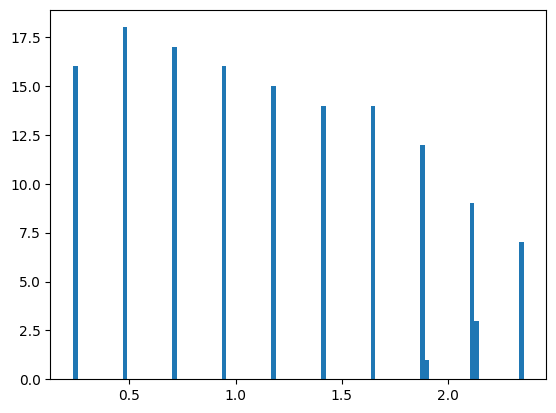

In [17]:
plt.hist(diffs, bins=100)

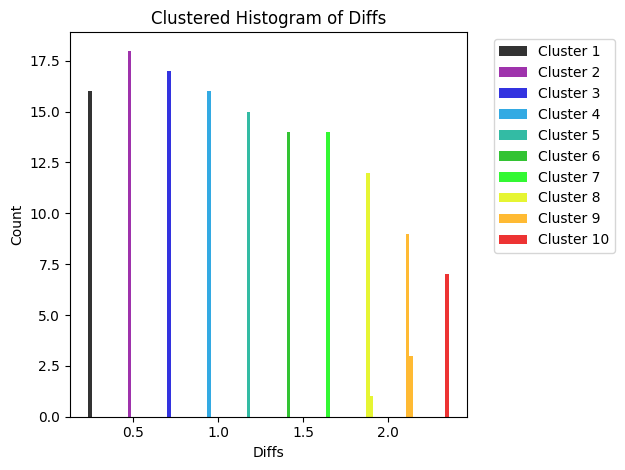

{0: {'mean': 0.2359, 'sd': 0.000595, 'n': 16, 'spread': 0.0016},
 1: {'mean': 0.4717, 'sd': 0.001149, 'n': 18, 'spread': 0.0035},
 2: {'mean': 0.7075, 'sd': 0.001686, 'n': 17, 'spread': 0.0064},
 3: {'mean': 0.9431, 'sd': 0.002055, 'n': 16, 'spread': 0.0075},
 4: {'mean': 1.1788, 'sd': 0.002338, 'n': 15, 'spread': 0.0082},
 5: {'mean': 1.4145, 'sd': 0.00244, 'n': 14, 'spread': 0.0078},
 6: {'mean': 1.6498, 'sd': 0.002719, 'n': 14, 'spread': 0.0095},
 7: {'mean': 1.8855, 'sd': 0.0027, 'n': 13, 'spread': 0.0083},
 8: {'mean': 2.1212, 'sd': 0.002828, 'n': 12, 'spread': 0.0084},
 9: {'mean': 2.3548, 'sd': 0.001121, 'n': 7, 'spread': 0.0029}}

In [18]:
# Choose a clustering method, cluster diffs, summarize each cluster

def dbscan_clustering(diffs, eps=0.006, min_samples=2):
    diffs = np.array(diffs).reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(diffs)
    labels = db.labels_
    unique_labels = sorted(set(labels))

    clusters = {}
    for id, label in enumerate(unique_labels):
        if label == -1:
            continue
        group = diffs[labels == label].flatten()
        if len(group) >= 2:
            clusters[id] = {
                'mean': round(float(np.mean(group)), 4),
                'sd': round(float(np.std(group)), 6),
                'n': len(group),
                'spread': round(float(max(group) - min(group)), 4)
            }
    plot_hist(diffs, labels)

    return clusters


def plot_hist(diffs, labels, bins=100):
    unique_labels = sorted(set(labels))
    n_labels = len(unique_labels)

    # Color map (enough for large numbers of clusters)
    cmap = plt.get_cmap('nipy_spectral')
    n_colors = 256  # resolution of the colormap
    step = 25       # how far to jump each time; higher = more distinct

    color_map = {
        label: cmap((i * step) % n_colors / (n_colors - 1))
        for i, label in enumerate(sorted(set(labels)))
    }


    # Histogram setup
    # bin_edges = np.histogram_bin_edges(diffs, bins=bins)
    bin_edges = np.linspace(diffs.min(), diffs.max(), bins + 1)
    for label in unique_labels:
        cluster_vals = diffs[labels == label].flatten()
        hist_vals, _ = np.histogram(cluster_vals, bins=bin_edges)
        plt.bar(bin_edges[:-1], hist_vals, width=np.diff(bin_edges),
                align='edge', alpha=0.8, label=f'Cluster {label + 1}' if label != -1 else 'Noise',
                color=color_map[label])

    plt.xlabel("Diffs")
    plt.ylabel("Count")
    plt.title("Clustered Histogram of Diffs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(False)
    plt.show()


clusters = dbscan_clustering(diffs, min_samples=int(sqrt(len(x))))
# clusters = dbscan_clustering_trimmed(diffs, min_samples=int(sqrt(len(x))))
clusters

Truth:

In [19]:
clusters = {cid: cluster for cid, cluster in clusters.items() if cluster['sd'] < cutoff} #and cluster['sd'] < 0.01}
clusters

{0: {'mean': 0.2359, 'sd': 0.000595, 'n': 16, 'spread': 0.0016},
 1: {'mean': 0.4717, 'sd': 0.001149, 'n': 18, 'spread': 0.0035},
 2: {'mean': 0.7075, 'sd': 0.001686, 'n': 17, 'spread': 0.0064},
 3: {'mean': 0.9431, 'sd': 0.002055, 'n': 16, 'spread': 0.0075},
 4: {'mean': 1.1788, 'sd': 0.002338, 'n': 15, 'spread': 0.0082},
 5: {'mean': 1.4145, 'sd': 0.00244, 'n': 14, 'spread': 0.0078},
 9: {'mean': 2.3548, 'sd': 0.001121, 'n': 7, 'spread': 0.0029}}

In [20]:

# from sklearn.cluster import DBSCAN
# import numpy as np
#
# def dbscan_clustering_trimmed(diffs, eps=0.005, min_samples=2, max_spread=0.006):
#     diffs = np.array(diffs).reshape(-1, 1)
#     db = DBSCAN(eps=eps, min_samples=min_samples).fit(diffs)
#     labels = db.labels_
#
#     clusters = {}
#     cluster_id = 0
#     for label in sorted(set(labels)):
#         if label == -1:
#             continue
#         group = diffs[labels == label].flatten()
#         if len(group) < 2:
#             continue
#
#         group = np.sort(group)
#
#         while len(group) >= 2 and (group[-1] - group[0]) > max_spread:
#             if (group[-1] - group[1]) < (group[-2] - group[0]):
#                 group = group[:-1]
#             else:
#                 group = group[1:]
#
#         if len(group) >= 2:
#             clusters[cluster_id] = {
#                 'mean': round(float(np.mean(group)), 4),
#                 'sd': round(float(np.std(group)), 6),
#                 'n': len(group),
#                 'spread': round(float(group[-1] - group[0]), 4)
#             }
#             cluster_id += 1
#
#     return clusters

In [21]:
# Count number of hits each cluster has

def count_hits_with_optimal_start(
    x, delta_t, sd, n, confidence=0.95, max_starts=10
):

    sd = mean_stdev
    x = np.array(x)
    se = sd / np.sqrt(n)
    z = norm.ppf(1 - (1 - confidence) / 2)
    margin = z * se

    best_hits = []
    best_tries = 0
    best_anchor = x[0]

    for i in range(min(max_starts, len(x))):
        anchor = x[i]
        hit_indices = []
        tries = 0
        last_hit = anchor

        while True:
            t = last_hit + delta_t
            if t > x[-1] + margin:
                break

            # Check for hit within margin
            candidates = np.where((x >= t - margin) & (x <= t + margin))[0]
            if candidates.size > 0:
                hit_idx = candidates[0]
                hit_indices.append(hit_idx)
                last_hit = x[hit_idx]  # Recenter from hit
            else:
                last_hit = t  # No hit — continue from expected

            tries += 1

        if len(hit_indices) > len(best_hits):
            best_hits = hit_indices
            best_tries = tries
            best_anchor = anchor

    return delta_t, best_anchor, len(best_hits), best_tries


def add_hit_data(clusters):
    for id, cluster in clusters.items():
        delta_t, anchor, hits, tries = count_hits_with_optimal_start(x, cluster["mean"], cluster["sd"], cluster["n"])
        cluster["anchor"] = anchor
        cluster["hits"] = hits
        cluster["tries"] = tries
    return clusters

clusters = add_hit_data(clusters)
clusters

{0: {'mean': 0.2359,
  'sd': 0.000595,
  'n': 16,
  'spread': 0.0016,
  'anchor': np.float64(1.2791),
  'hits': 9,
  'tries': 15},
 1: {'mean': 0.4717,
  'sd': 0.001149,
  'n': 18,
  'spread': 0.0035,
  'anchor': np.float64(1.2791),
  'hits': 2,
  'tries': 7},
 2: {'mean': 0.7075,
  'sd': 0.001686,
  'n': 17,
  'spread': 0.0064,
  'anchor': np.float64(1.2791),
  'hits': 2,
  'tries': 5},
 3: {'mean': 0.9431,
  'sd': 0.002055,
  'n': 16,
  'spread': 0.0075,
  'anchor': np.float64(1.7496),
  'hits': 2,
  'tries': 3},
 4: {'mean': 1.1788,
  'sd': 0.002338,
  'n': 15,
  'spread': 0.0082,
  'anchor': np.float64(1.2791),
  'hits': 2,
  'tries': 3},
 5: {'mean': 1.4145,
  'sd': 0.00244,
  'n': 14,
  'spread': 0.0078,
  'anchor': np.float64(0.3391),
  'hits': 1,
  'tries': 3},
 9: {'mean': 2.3548,
  'sd': 0.001121,
  'n': 7,
  'spread': 0.0029,
  'anchor': np.float64(0.5746),
  'hits': 1,
  'tries': 1}}

In [22]:
# Filter out insufficient hits (based on binomial distribution)

# from scipy.stats import binomtest
#
# def filter_delta_ts(hit_data, alpha=0.05, p_null=0.3):
#     return {
#         k: v for k, v in hit_data.items()
#         if binomtest(v["hits"], v["tries"], p_null, alternative="greater").pvalue < alpha
#     }

from scipy.stats import binom

def filter_delta_ts(hit_data, alpha=0.05, p_null=0.3):
    filtered = {}
    for k, v in hit_data.items():
        hits = v["hits"]
        tries = v["tries"]

        if tries < 2:
            continue

        # Compute P(X > hits)
        p_value = 1 - binom.cdf(hits, tries, p_null)

        if p_value < alpha:
            filtered[k] = v
    return filtered


filtered_clusters = filter_delta_ts(clusters)
filtered_clusters

{0: {'mean': 0.2359,
  'sd': 0.000595,
  'n': 16,
  'spread': 0.0016,
  'anchor': np.float64(1.2791),
  'hits': 9,
  'tries': 15},
 3: {'mean': 0.9431,
  'sd': 0.002055,
  'n': 16,
  'spread': 0.0075,
  'anchor': np.float64(1.7496),
  'hits': 2,
  'tries': 3},
 4: {'mean': 1.1788,
  'sd': 0.002338,
  'n': 15,
  'spread': 0.0082,
  'anchor': np.float64(1.2791),
  'hits': 2,
  'tries': 3}}

In [23]:
# Remove all integer multiples of lower frequencies

def prob_integer_multiple(base, sd_base, n_base, candidate, sd_candidate, n_candidate):
    """
    Computes the probability that the candidate mean is an integer multiple of the base mean,
    using propagated standard error.

    Parameters:
    - base, sd_base, n_base: mean, std, and sample size of base cluster
    - candidate, sd_candidate, n_candidate: same for candidate cluster

    Returns:
    - best_k: closest integer multiple
    - probability: two-tailed probability that ratio ≈ k
    """
    ratio = candidate / base
    if sd_base == 0 or sd_candidate == 0: # synthetic data with no deviation
        return 1 if ratio == round(ratio) else 0
    best_k = round(ratio)

    # Use standard error (not just std dev)
    se_base = sd_base / sqrt(n_base)
    se_candidate = sd_candidate / sqrt(n_candidate)

    # Error propagation for ratio
    ratio_se = ratio * sqrt((se_candidate / candidate)**2 + (se_base / base)**2)

    z = abs(ratio - best_k) / ratio_se
    probability = 2 * (1 - norm.cdf(z))  # two-tailed

    return probability


def remove_integer_multiples(clusters_dict, p_thresh=0.05):
    cluster_ids = list(clusters_dict.keys())
    keep = {cid: True for cid in cluster_ids}

    for i in range(len(cluster_ids) - 1):
        ci_id = cluster_ids[i]
        if not keep[ci_id]:
            continue
        for j in range(i + 1, len(cluster_ids)):
            cj_id = cluster_ids[j]
            if not keep[cj_id]:
                continue

            ci = clusters_dict[ci_id]
            cj = clusters_dict[cj_id]

            p = prob_integer_multiple(
                base=ci["mean"], sd_base=ci["sd"], n_base=ci["n"],
                candidate=cj["mean"], sd_candidate=cj["sd"], n_candidate=cj["n"]
            )

            if p > p_thresh:
                keep[cj_id] = False

    # Return a new dictionary with only the clusters to keep
    pruned = {cid: clusters_dict[cid] for cid in cluster_ids if keep[cid]}
    return pruned

base_diffs = remove_integer_multiples(filtered_clusters)
base_diffs

{0: {'mean': 0.2359,
  'sd': 0.000595,
  'n': 16,
  'spread': 0.0016,
  'anchor': np.float64(1.2791),
  'hits': 9,
  'tries': 15}}

In [24]:
# Extract number of base_diffs and mean of each base diff

# def extract_means(base_diffs):
#     cluster_0_mean = base_diffs[0]["mean"] if 0 in base_diffs else 0
#     cluster_1_mean = base_diffs[1]["mean"] if 1 in base_diffs else 0
#     cluster_2_mean = base_diffs[2]["mean"] if 2 in base_diffs else 0
#     return [float(cluster_0_mean), float(cluster_1_mean), float(cluster_2_mean)]
#
#
# result = extract_means(base_diffs)
# result

In [25]:
# def multiple_boilings(peaks):
#     diffs = get_diffs(peaks)
#     clusters = pmm_clustering(diffs)
#     clusters = add_hit_data(clusters)
#     filtered_clusters = filter_delta_ts(clusters)
#     base_diffs = remove_integer_multiples(filtered_clusters)
#     result = extract_means(base_diffs)
#     return result
#
# def number_of_boilings(peaks):
#     diffs = get_diffs(peaks)
#     clusters = pmm_clustering(diffs)
#     clusters = add_hit_data(clusters)
#     filtered_clusters = filter_delta_ts(clusters)
#     base_diffs = remove_integer_multiples(filtered_clusters)
#     return len(base_diffs)
#
# number_of_boilings(x)